<a href="https://colab.research.google.com/github/Arrsssa/-/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B4%80%EB%A6%AC%EB%A1%A0_%EC%88%99%EC%A0%9C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# seaborn tips 데이터 분석

## 목표
1. tip 변수의 분포를 확인한다
2. 평균과 분산을 계산한다
3. 3가지 표본추출방법을 비교한다

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
tip_data = tips["tip"]

print("tip mean:", tip_data.mean())
print("tip variance:", tip_data.var())
print(tip_data.describe())

tip mean: 2.99827868852459
tip variance: 1.9144546380624725
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64


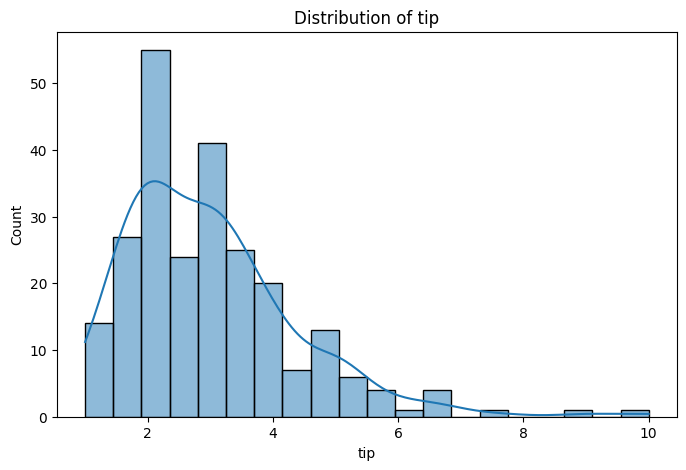

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(tip_data, bins=20, kde=True)
plt.title("Distribution of tip")
plt.show()

In [7]:
population_mean = tips["tip"].mean()
population_var = tips["tip"].var()

print("population mean:", population_mean)
print("population variance:", population_var)

population mean: 2.99827868852459
population variance: 1.9144546380624725


In [8]:
random_sample = tips.sample(n=50, random_state=42)

In [9]:
systematic_sample = tips.iloc[::5]

In [10]:
stratified_sample = tips.groupby("sex", group_keys=False).apply(
    lambda x: x.sample(n=min(25, len(x)), random_state=42)
)

/tmp/ipykernel_416/2326205634.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = tips.groupby("sex", group_keys=False).apply(
/tmp/ipykernel_416/2326205634.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby("sex", group_keys=False).apply(


In [11]:
comparison = pd.DataFrame({
    "Group": ["Population", "Random", "Systematic", "Stratified"],
    "Mean": [
        tips["tip"].mean(),
        random_sample["tip"].mean(),
        systematic_sample["tip"].mean(),
        stratified_sample["tip"].mean()
    ],
    "Variance": [
        tips["tip"].var(),
        random_sample["tip"].var(),
        systematic_sample["tip"].var(),
        stratified_sample["tip"].var()
    ]
})

comparison

,Group,Mean,Variance
0,Population,2.998279,1.914455
1,Random,2.643600,1.250093
2,Systematic,2.940408,2.369300
3,Stratified,3.243800,1.841567


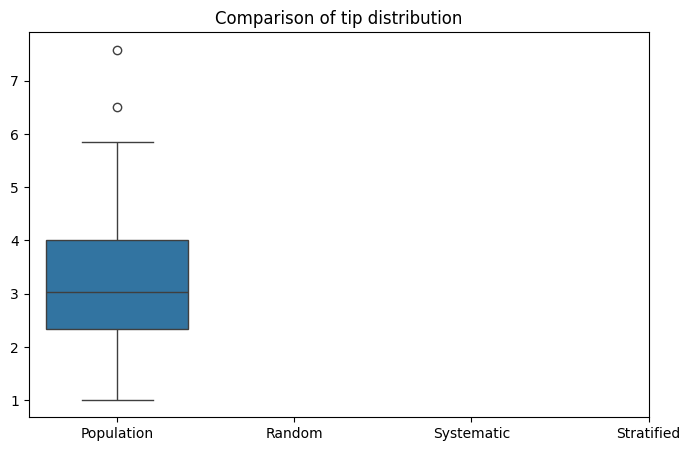

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[
    tips["tip"],
    random_sample["tip"],
    systematic_sample["tip"],
    stratified_sample["tip"]
])

plt.xticks([0,1,2,3], ["Population","Random","Systematic","Stratified"])
plt.title("Comparison of tip distribution")
plt.show()

### 결론

tip 데이터는 오른쪽으로 치우친 분포를 보인다.
평균은 이상치의 영향을 받을 수 있기 때문에 분포와 분산을 함께 확인해야 한다.

3가지 표본추출방법을 비교한 결과 모집단의 평균과 분산에 가장 가까운 방법이 가장 적합한 표본추출방법이라고 볼 수 있다.